# Kernel PCA

**Idea:** PCA can only *rotate* the data. If the structure is non-linear, it doesn't help.
Kernel PCA first maps the data to a higher-dimensional space (via a kernel) and applies PCA **there**.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.decomposition import PCA, KernelPCA

## 1. The data: two rings

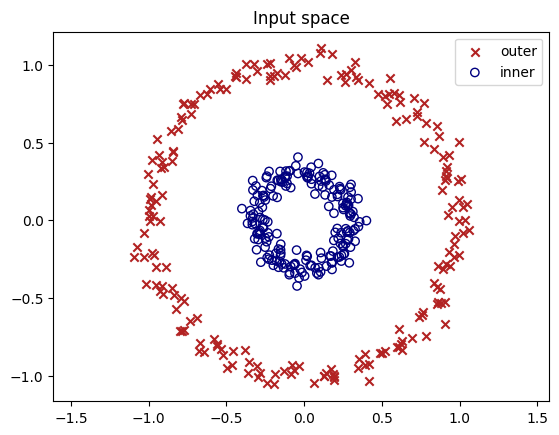

In [2]:
X, y = make_circles(n_samples=400, factor=0.3, noise=0.05, random_state=0)

plt.scatter(X[y==0, 0], X[y==0, 1], c='firebrick', marker='x', label='outer')
plt.scatter(X[y==1, 0], X[y==1, 1], facecolors='none', edgecolors='navy', label='inner')
plt.axis('equal'); plt.legend(); plt.title('Input space');

## 2. Linear PCA

It just rotates the axes → the rings stay just as mixed.

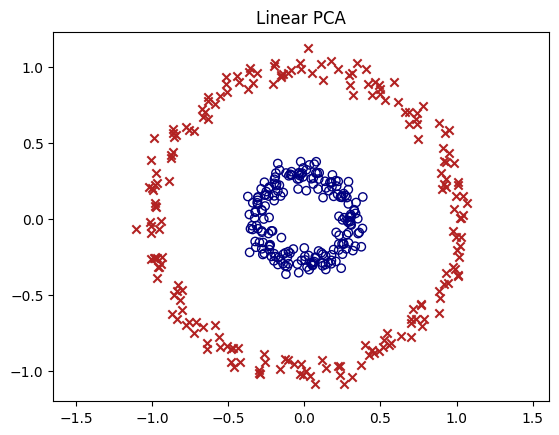

In [3]:
X_pca = PCA(n_components=2).fit_transform(X)

plt.scatter(X_pca[y==0, 0], X_pca[y==0, 1], c='firebrick', marker='x')
plt.scatter(X_pca[y==1, 0], X_pca[y==1, 1], facecolors='none', edgecolors='navy')
plt.axis('equal'); plt.title('Linear PCA');

## 3. Kernel PCA (RBF)

RBF kernel: $k(x, x') = e^{-\gamma \|x - x'\|^2}$ → measures *closeness*.

Points in the same ring are similar to each other → they end up separated.

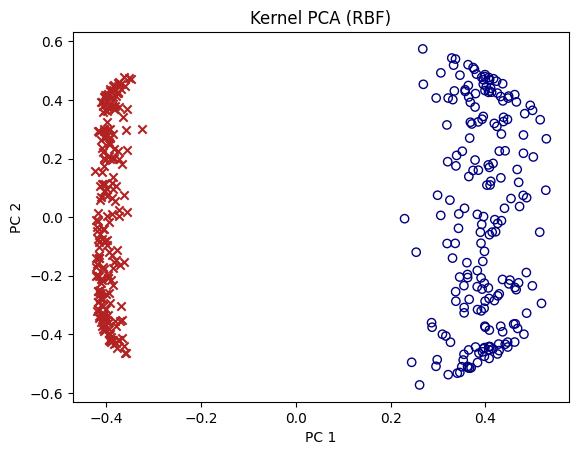

In [4]:
X_kpca = KernelPCA(n_components=2, kernel='rbf', gamma=3).fit_transform(X)

plt.scatter(X_kpca[y==0, 0], X_kpca[y==0, 1], c='firebrick', marker='x')
plt.scatter(X_kpca[y==1, 0], X_kpca[y==1, 1], facecolors='none', edgecolors='navy')
plt.xlabel('PC 1'); plt.ylabel('PC 2'); plt.title('Kernel PCA (RBF)');

**Conclusion:** on PC 1 of kernel PCA, a single vertical line separates the rings.

👉 Try changing `gamma` (1, 3, 10) and see what happens.